<div style="
    max-width: 1200px;
    margin: 18px auto; 
    padding: 50px 30px; 
    background: rgba(120, 120, 120, 0.05); 
    border-radius: 20px; 
    border: 1px solid rgba(120, 120, 120, 0.1);
    box-shadow: 0 10px 30px rgba(0,0,0,0.15);
    text-align: center;
">
    <h1 style="
        margin: 0; 
        background: linear-gradient(90deg, #6a11cb 0%, #2575fc 100%); 
        -webkit-background-clip: text; 
        -webkit-text-fill-color: transparent; 
        font-family: 'Segoe UI', sans-serif; 
        font-weight: 800; 
        font-size: 3em;
    ">
        Bank Marketing Project - Model Training & Evaluation
    </h1>
    <p style="
        font-size: 1.2em; 
        opacity: 0.8; 
        margin: 15px 0 0 0; 
        font-family: 'Segoe UI', sans-serif; 
        letter-spacing: 1px;
        line-height: 1.8;
    ">
       Track: AI - Intake 46 - Alexandria
       <br/>
       Subject: Bank Marketing Project - Modeling Phase 
       <br/>
       Team Members: Abdallah Mohamed - Ahmed Gamal - Ahmed Saleem
    </p>
</div>

<div style="
  width: 97%;
  margin: 12px 0;
  padding: 16px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.08);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.10);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; top: 0; bottom: 0;
    width: 5px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <div style="
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    color: inherit;
  ">
    <p style="
      margin: 0;
      font-size: 1em;
      line-height: 1.75;
      opacity: 0.90;
    ">
      Notebook (3) (model_training.ipynb): In this notebook, we build on the cleaned and engineered dataset produced in Notebook (2). We will select features, build a proper preprocessing pipeline, train and tune 5 classification models, evaluate them thoroughly, and export the best model for deployment.
    </p>
  </div>
</div>

<div style="
    max-width: 1200px;
    margin: 18px auto;
    padding: 18px 25px;
    background: linear-gradient(90deg, #5e0ab9 0%,#6a11cb 30%, #3f84fd 100%);
    border-radius: 14px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.2);
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        letter-spacing: 2px;
        font-weight: 700;
        font-family: 'Segoe UI', sans-serif;
    ">
        0. Imports
    </h2>
</div>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_recall_curve,
    average_precision_score, accuracy_score
)

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

<div style="
    max-width: 1200px;
    margin: 18px auto;
    padding: 18px 25px;
    background: linear-gradient(90deg, #5e0ab9 0%,#6a11cb 30%, #3f84fd 100%);
    border-radius: 14px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.2);
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        letter-spacing: 2px;
        font-weight: 700;
        font-family: 'Segoe UI', sans-serif;
    ">
        1. Load & Prepare Data
    </h2>
</div>

In [39]:
df = pd.read_csv('dataset/processed_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nImbalance ratio: {df['target'].value_counts()[0] / df['target'].value_counts()[1]:.1f} : 1")
df.head()

Dataset shape: (45211, 19)

Target distribution:
target
0    39922
1     5289
Name: count, dtype: int64

Imbalance ratio: 7.5 : 1


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,target,high_month,age_group,balance_group,pdays_cleaned
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,unknown,0,0,Senior (45-60),Medium (1k-5k),901
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,unknown,0,0,Adult (30-45),Low (1-1k),901
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,unknown,0,0,Adult (30-45),Low (1-1k),901
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,unknown,0,0,Senior (45-60),Medium (1k-5k),901
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,unknown,0,0,Adult (30-45),Low (1-1k),901


<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    1.1 Feature Engineering & Selection
  </h3>
</div>

<div style="
  width: 97%;
  margin: 12px 0;
  padding: 16px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.08);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.10);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; top: 0; bottom: 0;
    width: 5px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <div style="
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    color: inherit;
  ">
    <p style="margin: 0 0 10px 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      Based on the EDA findings, we make the following feature decisions:
    </p>
    <ul style="margin: 0; padding-left: 18px; font-size: 0.95em; line-height: 1.9; opacity: 0.90;">
      <li><b>Drop <code>default</code></b> &mdash; 98% of values are "no", so it has near-zero variance and adds noise.</li>
      <li><b>Drop <code>day</code></b> &mdash; EDA showed weak correlation with the target and no clear pattern (Q14/Q31).</li>
      <li><b>Keep raw <code>age</code> + <code>age_group</code></b> &mdash; Raw age captures the magnitude, while the binned version captures the U-shaped pattern found in the EDA (Q24: both young and elderly subscribe more).</li>
      <li><b>Keep raw <code>balance</code> + <code>balance_group</code></b> &mdash; Raw captures the actual amount, bins handle the heavy right-skew (EDA Q26).</li>
      <li><b>Create <code>was_contacted_before</code></b> &mdash; The <code>pdays_cleaned</code> column has value 901 for 82% of rows (meaning never contacted). A binary flag (yes/no) is more informative than a noisy number.</li>
      <li><b>Keep <code>poutcome</code></b> &mdash; The strongest predictor by far: clients who previously subscribed convert at 64.7% (EDA Q23).</li>
      <li><b>Keep <code>high_month</code></b> &mdash; Captures the seasonal pattern where March, September, October, and December have the highest subscription rates (EDA Q22).</li>
    </ul>
  </div>
</div>

In [40]:
# Create binary contact-history flag
df['was_contacted_before'] = (df['pdays_cleaned'] != 901).astype(int)

# Drop low-value features
drop_cols = ['default', 'day', 'pdays_cleaned']
df = df.drop(columns=drop_cols)

print(f"Shape after feature selection: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape after feature selection: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'previous', 'poutcome', 'target', 'high_month', 'age_group', 'balance_group', 'was_contacted_before']


<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    1.2 Define Feature Groups
  </h3>
</div>

In [41]:
target = 'target'

# Nominal categoricals -> OneHotEncoding
cat_cols = ['job', 'marital', 'education', 'housing', 'loan',
            'contact', 'month', 'poutcome', 'age_group', 'balance_group']

# Numeric features -> StandardScaler
num_cols = ['age', 'balance', 'campaign', 'previous', 'high_month', 'was_contacted_before']

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numeric features ({len(num_cols)}):     {num_cols}")
print(f"Total features: {len(cat_cols) + len(num_cols)}")

Categorical features (10): ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group', 'balance_group']
Numeric features (6):     ['age', 'balance', 'campaign', 'previous', 'high_month', 'was_contacted_before']
Total features: 16


<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    1.3 Train / Test Split
  </h3>
</div>

In [42]:
X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples  |  Test: {X_test.shape[0]:,} samples")
print(f"\nTrain target distribution:")
print(y_train.value_counts())

Train: 36,168 samples  |  Test: 9,043 samples

Train target distribution:
target
0    31937
1     4231
Name: count, dtype: int64


<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    1.4 Preprocessing Pipeline
  </h3>
</div>

<div style="
  width: 97%;
  margin: 12px 0;
  padding: 16px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.08);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.10);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; top: 0; bottom: 0;
    width: 5px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <div style="
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    color: inherit;
  ">
    <p style="margin: 0 0 10px 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      We use a <code>ColumnTransformer</code> to apply different transformations to different feature types:
    </p>
    <ul style="margin: 0; padding-left: 18px; font-size: 0.95em; line-height: 1.9; opacity: 0.90;">
      <li><b>Numeric features</b> &rarr; <code>StandardScaler</code> (zero mean, unit variance) &mdash; ensures all numeric features are on the same scale so no single feature dominates.</li>
      <li><b>Categorical features</b> &rarr; <code>OneHotEncoder</code> (binary columns) &mdash; creates a separate 0/1 column for each category. This is better than LabelEncoder which assigns numbers like 0, 1, 2 and tricks the model into thinking there is an order between categories.</li>
      <li><b>Class imbalance</b> &rarr; Handled using <code>class_weight='balanced'</code> and <code>scale_pos_weight</code> built into the models &mdash; this tells the model to pay more attention to the minority class (subscribers) without creating synthetic samples.</li>
    </ul>
  </div>
</div>

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

print("Preprocessor defined.")
print("  Numeric     -> StandardScaler")
print("  Categorical -> OneHotEncoder")

Preprocessor defined.
  Numeric     -> StandardScaler
  Categorical -> OneHotEncoder


<div style="
    max-width: 1200px;
    margin: 18px auto;
    padding: 18px 25px;
    background: linear-gradient(90deg, #5e0ab9 0%,#6a11cb 30%, #3f84fd 100%);
    border-radius: 14px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.2);
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        letter-spacing: 2px;
        font-weight: 700;
        font-family: 'Segoe UI', sans-serif;
    ">
        2. Model Training & Hyperparameter Tuning
    </h2>
</div>

<div style="
  width: 97%;
  margin: 12px 0;
  padding: 16px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.08);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.10);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; top: 0; bottom: 0;
    width: 5px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <div style="
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    color: inherit;
  ">
    <p style="margin: 0 0 10px 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      We train <b>5 models</b> using <code>GridSearchCV</code> with 5-fold Stratified Cross-Validation. Each model is wrapped inside a full sklearn <code>Pipeline</code> (preprocessor + model) so that encoding and scaling happen inside each CV fold, preventing data leakage.
    </p>
    <p style="margin: 0 0 10px 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      <b>Scoring metric: AUC-ROC</b> &mdash; We optimize for AUC instead of accuracy or F1 because our dataset is heavily imbalanced (88% no, 12% yes). AUC measures how well the model <i>ranks</i> positive cases higher than negative ones, regardless of threshold.
    </p>
    <p style="margin: 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      <b>Models:</b> Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and Neural Network (MLP).
    </p>
  </div>
</div>

In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__class_weight': ['balanced', None]
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'model__n_estimators': [200, 300],
            'model__max_depth': [10, 20, None],
            'model__min_samples_split': [5, 10],
            'model__class_weight': ['balanced', 'balanced_subsample']
        }
    },
    'Gradient Boosting': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingClassifier(random_state=42))
        ]),
        'params': {
            'model__n_estimators': [200, 300],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__subsample': [0.8, 1.0]
        }
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', XGBClassifier(eval_metric='logloss', random_state=42))
        ]),
        'params': {
            'model__n_estimators': [200, 300],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__subsample': [0.8, 1.0],
            'model__scale_pos_weight': [1, 5, 7]
        }
    },
    'Neural Network (MLP)': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', MLPClassifier(max_iter=300, random_state=42, early_stopping=True,
                                    validation_fraction=0.1))
        ]),
        'params': {
            'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (50, 25)],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': [0.0001, 0.001, 0.01],
            'model__learning_rate_init': [0.001, 0.01]
        }
    }
}

In [ ]:
results = {}

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")
    
    grid = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_train, y_train)
    
    y_pred = grid.best_estimator_.predict(X_test)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    test_f1  = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob)
    test_acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_auc': grid.best_score_,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'test_acc': test_acc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"  Best params:  {grid.best_params_}")
    print(f"  CV AUC-ROC:   {grid.best_score_:.4f}")
    print(f"  Test AUC-ROC: {test_auc:.4f}")
    print(f"  Test F1:      {test_f1:.4f}")
    print(f"  Test Accuracy:{test_acc:.4f}")

<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    2.1 Model Comparison Summary
  </h3>
</div>

In [45]:
comparison = pd.DataFrame({
    'Model': results.keys(),
    'CV AUC': [r['cv_auc'] for r in results.values()],
    'Test AUC': [r['test_auc'] for r in results.values()],
    'Test F1': [r['test_f1'] for r in results.values()],
    'Test Accuracy': [r['test_acc'] for r in results.values()]
}).sort_values('Test AUC', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))

               Model   CV AUC  Test AUC  Test F1  Test Accuracy
   Gradient Boosting 0.782211  0.791272 0.334490       0.893951
             XGBoost 0.782998  0.790473 0.471642       0.862988
       Random Forest 0.780066  0.789494 0.438267       0.827933
Neural Network (MLP) 0.778470  0.785084 0.307132       0.894725
 Logistic Regression 0.770727  0.779574 0.392899       0.769324


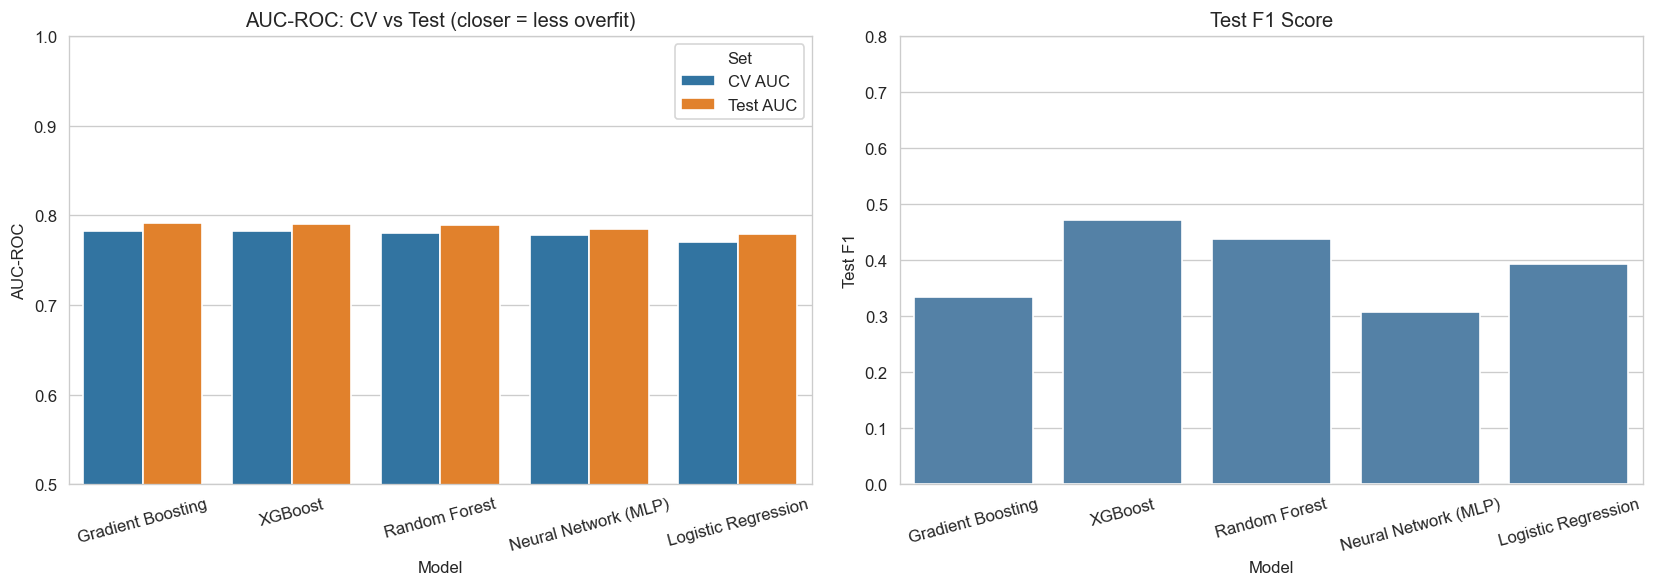

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison — CV vs Test (check for overfitting)
auc_melted = comparison.melt(id_vars='Model', value_vars=['CV AUC', 'Test AUC'],
                              var_name='Set', value_name='AUC-ROC')
sns.barplot(data=auc_melted, x='Model', y='AUC-ROC', hue='Set', ax=axes[0])
axes[0].set_title('AUC-ROC: CV vs Test (closer = less overfit)')
axes[0].set_ylim(0.5, 1)
axes[0].tick_params(axis='x', rotation=15)

# F1 comparison
sns.barplot(data=comparison, x='Model', y='Test F1', ax=axes[1], color='steelblue')
axes[1].set_title('Test F1 Score')
axes[1].set_ylim(0, 0.8)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>AUC-ROC Bar Chart (CV vs Test):</b> Shows two bars per model &mdash; one for cross-validation AUC and one for test AUC. When both bars are nearly the same height, it means the model is not overfitting. If the CV bar were much taller than the test bar, it would mean the model memorized training data and failed on new data.</p>
</div></div>

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>F1 Score vs Threshold Plot:</b> Shows how F1 changes as we move the decision threshold. The peak of this curve is the optimal threshold. Notice that F1 at 0.50 is far from the peak &mdash; this is typical for imbalanced datasets where the optimal threshold is much lower than 0.5.</p>
</div></div>

<div style="
    max-width: 1200px;
    margin: 18px auto;
    padding: 18px 25px;
    background: linear-gradient(90deg, #5e0ab9 0%,#6a11cb 30%, #3f84fd 100%);
    border-radius: 14px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.2);
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        letter-spacing: 2px;
        font-weight: 700;
        font-family: 'Segoe UI', sans-serif;
    ">
        3. Threshold Tuning
    </h2>
</div>

<div style="
  width: 97%;
  margin: 12px 0;
  padding: 16px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.08);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.10);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; top: 0; bottom: 0;
    width: 5px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <div style="
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    color: inherit;
  ">
    <p style="margin: 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      By default, classifiers use a threshold of 0.5 to decide: if the predicted probability is above 0.5, it predicts "yes". But with our imbalanced data (only 12% subscribers), most probabilities are low, so very few get classified as "yes" at 0.5. We sweep across all thresholds from 0.1 to 0.9 and pick the one that maximizes F1 score.
    </p>
  </div>
</div>

In [47]:
# Select the best model based on Test AUC
best_name = comparison.iloc[0]['Model']
best = results[best_name]

print(f"Best model: {best_name}")
print(f"Best params: {best['best_params']}")
print(f"\nWith default threshold (0.5):")
print(f"  Test AUC: {best['test_auc']:.4f}  |  Test F1: {best['test_f1']:.4f}  |  Accuracy: {best['test_acc']:.4f}")

Best model: Gradient Boosting
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}

With default threshold (0.5):
  Test AUC: 0.7913  |  Test F1: 0.3345  |  Accuracy: 0.8940


In [57]:
# Find optimal threshold by maximizing F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (best['y_prob'] >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

optimal_threshold = thresholds[np.argmax(f1_scores)]
best_f1_tuned = max(f1_scores)

# Apply optimal threshold
y_pred_tuned = (best['y_prob'] >= optimal_threshold).astype(int)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"\nWith tuned threshold ({optimal_threshold:.2f}):")
print(f"  Test AUC: {best['test_auc']:.4f}  |  Test F1: {best_f1_tuned:.4f}  |  Accuracy: {acc_tuned:.4f}")
print(f"\nF1 improvement: {best['test_f1']:.4f} -> {best_f1_tuned:.4f} (+{best_f1_tuned - best['test_f1']:.4f})")

Optimal threshold: 0.18

With tuned threshold (0.18):
  Test AUC: 0.7913  |  Test F1: 0.4776  |  Accuracy: 0.8696

F1 improvement: 0.3345 -> 0.4776 (+0.1431)


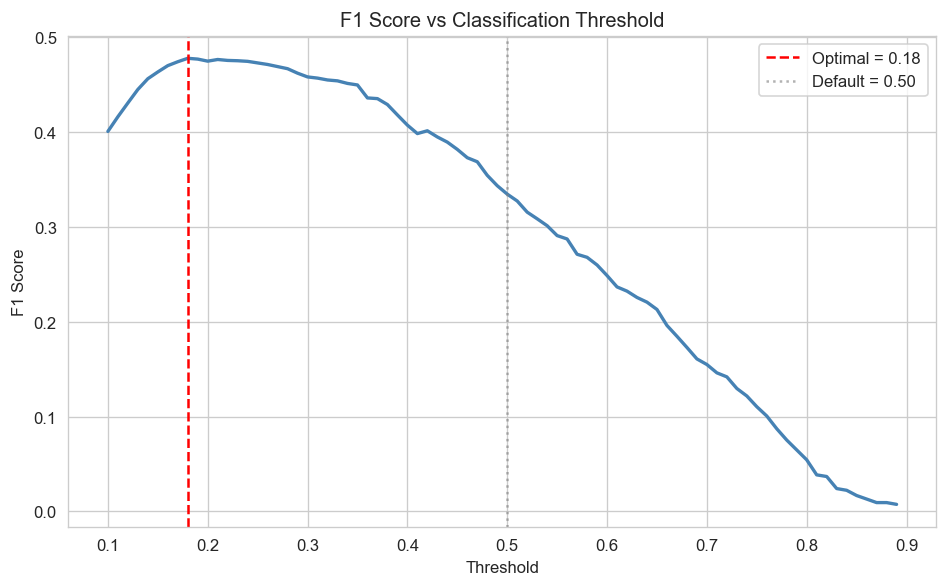

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
ax.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal = {optimal_threshold:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.6, label='Default = 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Classification Threshold')
ax.legend()
plt.tight_layout()
plt.show()

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px; text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18); box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;"> <div style="position:absolute;left:0;top:0;bottom:0;width:5px; background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div> <div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;"> <p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;">The F1 score peaks at threshold <b>0.18</b> (red line) with F1 = 0.48, then drops steadily as the threshold increases. At the default 0.50 (gray line), F1 is only 0.33. This means the model gives most subscribers a low probability, so we need a lower cutoff to catch them. Simply changing the threshold from 0.50 to 0.18 boosted F1 by <b>+0.14</b> with no model changes.</p> </div></div>

<div style="
    max-width: 1200px;
    margin: 18px auto;
    padding: 18px 25px;
    background: linear-gradient(90deg, #5e0ab9 0%,#6a11cb 30%, #3f84fd 100%);
    border-radius: 14px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.2);
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        letter-spacing: 2px;
        font-weight: 700;
        font-family: 'Segoe UI', sans-serif;
    ">
        4. Detailed Evaluation (Tuned Threshold)
    </h2>
</div>

<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    4.1 Classification Report
  </h3>
</div>

In [50]:
print(f"Classification Report — {best_name} (threshold={optimal_threshold:.2f})")
print("=" * 60)
print(classification_report(y_test, y_pred_tuned, target_names=['No (0)', 'Yes (1)']))

Classification Report — Gradient Boosting (threshold=0.18)
              precision    recall  f1-score   support

      No (0)       0.93      0.92      0.93      7985
     Yes (1)       0.45      0.51      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.71      0.70      9043
weighted avg       0.88      0.87      0.87      9043



<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    4.2 Confusion Matrix
  </h3>
</div>

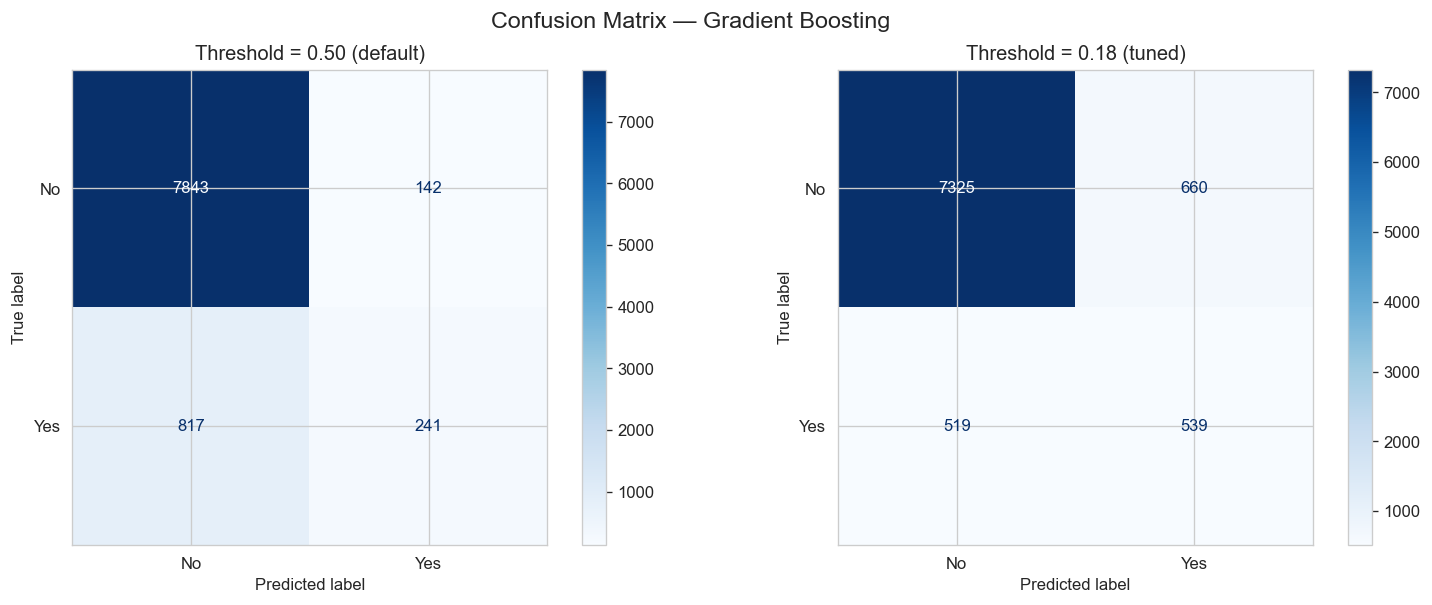

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Default threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, best['y_pred'],
    display_labels=['No', 'Yes'], cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Threshold = 0.50 (default)')

# Tuned threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['No', 'Yes'], cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Threshold = {optimal_threshold:.2f} (tuned)')

plt.suptitle(f'Confusion Matrix — {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>Confusion Matrix (Default vs Tuned):</b> The left matrix (threshold=0.50) shows very few "Yes" predictions &mdash; high precision but terrible recall (it misses most subscribers). The right matrix (tuned threshold) catches many more subscribers (higher recall) at the cost of some false positives. For a marketing campaign, catching more real subscribers is usually worth a few extra calls to non-subscribers. accuracy drops slightly (89% → 87%) but we find twice as many subscribers (241 → 539).</p>
</div></div>

<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    4.3 ROC Curves (All Models)
  </h3>
</div>

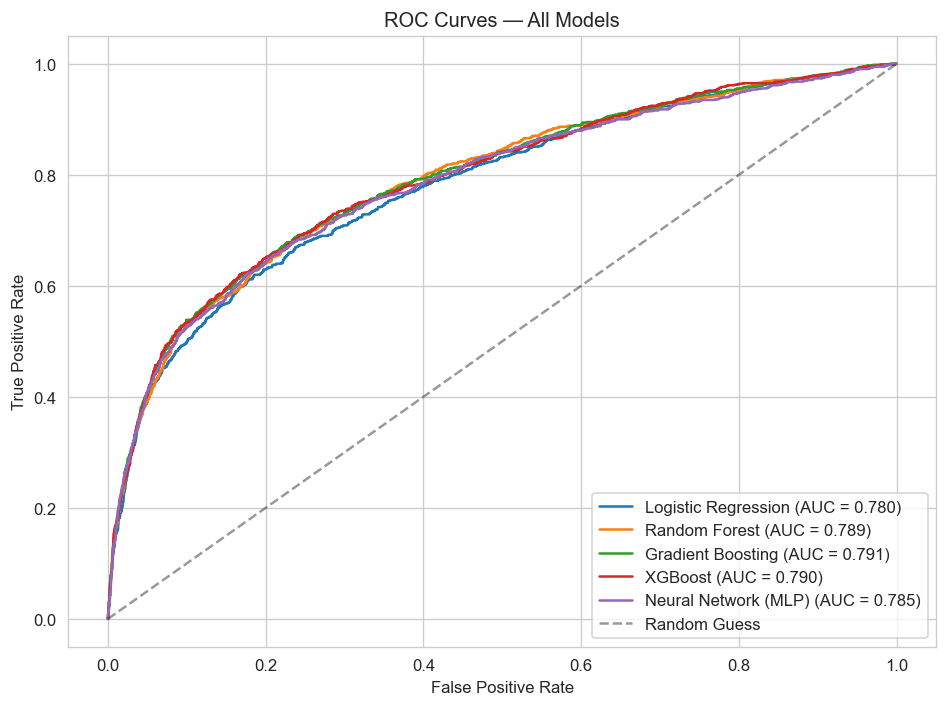

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['test_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>ROC Curves:</b> Each curve shows the trade-off between True Positive Rate (catching subscribers) and False Positive Rate (incorrectly flagging non-subscribers) across all thresholds. A curve closer to the top-left corner is better. The dashed diagonal line represents random guessing. All our models are well above random, with Gradient Boosting having the largest area under the curve.</p>
</div></div>

<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    4.4 Precision-Recall Curves (All Models)
  </h3>
</div>

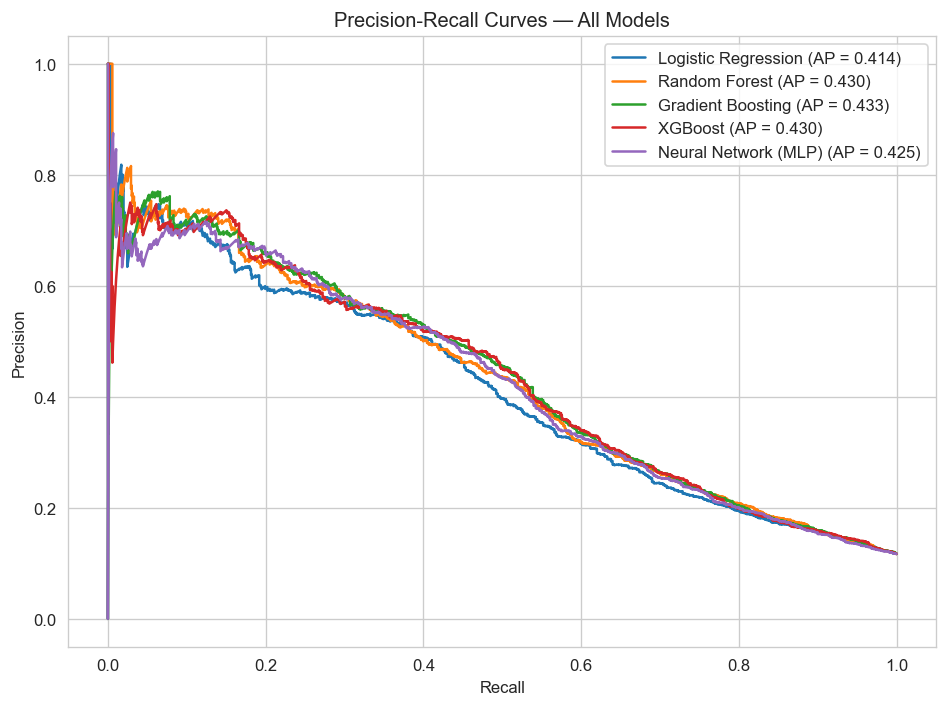

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    ax.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>Precision-Recall Curves:</b> Especially important for imbalanced data. Shows the trade-off between Precision (how many of the predicted subscribers are real) and Recall (how many of the real subscribers were found). A curve closer to the top-right corner is better. The Average Precision (AP) number summarizes the overall quality &mdash; higher AP means the model is better at finding subscribers without too many false alarms.</p>
</div></div>

<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    4.5 Feature Importance
  </h3>
</div>

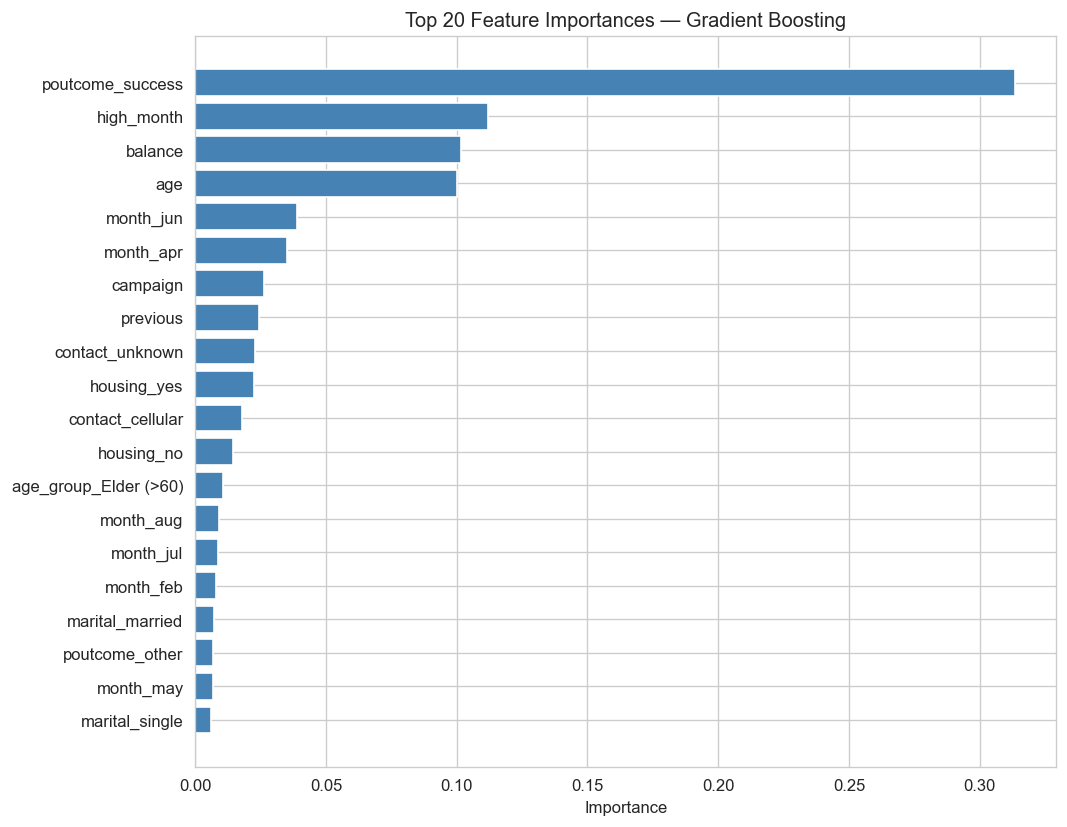

In [54]:
best_pipeline = best['best_estimator']
best_model = best_pipeline.named_steps['model']

# Get feature names after OneHotEncoding
ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_feature_names

# Get importances (tree-based or coefficients)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    # For MLP: use permutation importance
    from sklearn.inspection import permutation_importance
    X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)
    perm = permutation_importance(best_model, X_test_transformed, y_test,
                                  n_repeats=10, random_state=42, scoring='roc_auc')
    importances = perm.importances_mean

feat_imp = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Show top 20
top_n = feat_imp.head(20).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_n['Feature'], top_n['Importance'], color='steelblue')
ax.set_title(f'Top 20 Feature Importances — {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>Feature Importance:</b> Shows which features the model relies on most to make predictions. The results confirm what we found in the EDA &mdash; <code>poutcome_success</code> (whether the client subscribed before) is the most important feature, followed by contact method, month, and housing loan status.</p>
</div></div>

<div style="
  width: 97%;
  margin: 18px 0;
  padding: 14px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.10);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.12);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; 
    top: 0; 
    bottom: 0;
    width: 6px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <h3 style="
    margin: 0;
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    font-weight: 800;
    letter-spacing: 1px;
    font-size: 1.25em;
    color: inherit;
  ">
    4.6 Cumulative Lift Curve
  </h3>
</div>

<div style="
  width: 97%;
  margin: 12px 0;
  padding: 16px 18px;
  border-radius: 12px;
  text-align: left;
  background: rgba(140, 140, 140, 0.08);
  border: 1px solid rgba(140, 140, 140, 0.18);
  box-shadow: 0 6px 18px rgba(0,0,0,0.10);
  backdrop-filter: blur(10px);
  position: relative;
  overflow: hidden;
">
  <div style="
    position: absolute;
    left: 0; top: 0; bottom: 0;
    width: 5px;
    background: linear-gradient(180deg, #5e0ab9 0%, #6a11cb 55%, #3f84fd 100%);
  "></div>
  <div style="
    padding-left: 12px;
    font-family: 'Segoe UI', sans-serif;
    color: inherit;
  ">
    <p style="margin: 0; font-size: 1em; line-height: 1.75; opacity: 0.90;">
      The Lift curve answers a practical business question: "If the bank can only contact a fraction of its clients, how many actual subscribers would it capture?" We rank all clients by their predicted probability (highest first) and plot what percentage of real subscribers fall within each contacted percentage.
    </p>
  </div>
</div>

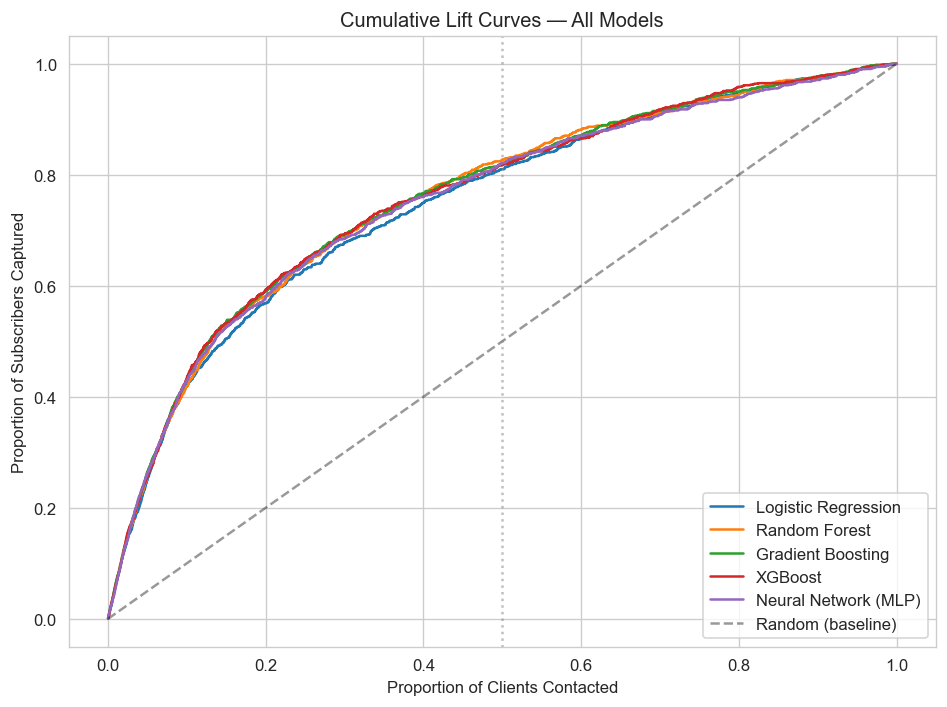


Subscribers captured by contacting top 50% of clients:
  Logistic Regression: 81.0%
  Random Forest: 82.7%
  Gradient Boosting: 82.0%
  XGBoost: 81.8%
  Neural Network (MLP): 82.0%


In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    # Sort by predicted probability (descending)
    sorted_idx = np.argsort(-res['y_prob'])
    y_sorted = y_test.values[sorted_idx]
    
    # Cumulative gain
    cum_positives = np.cumsum(y_sorted)
    total_positives = y_sorted.sum()
    x_pct = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    y_pct = cum_positives / total_positives
    
    ax.plot(x_pct, y_pct, label=name)

# Baseline (random)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (baseline)')
ax.set_xlabel('Proportion of Clients Contacted')
ax.set_ylabel('Proportion of Subscribers Captured')
ax.set_title('Cumulative Lift Curves — All Models')
ax.legend(loc='lower right')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Print: by contacting top 50% of clients, how many subscribers do we capture?
print("\nSubscribers captured by contacting top 50% of clients:")
for name, res in results.items():
    sorted_idx = np.argsort(-res['y_prob'])
    y_sorted = y_test.values[sorted_idx]
    half = len(y_sorted) // 2
    captured = y_sorted[:half].sum() / y_sorted.sum()
    print(f"  {name}: {captured:.1%}")

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>Cumulative Lift Curve:</b> The most business-relevant chart. It answers: "If we can only contact X% of clients, what percentage of actual subscribers will we reach?" The diagonal line represents random selection (contact 50%, catch 50%). Our best model shows that by contacting only the top 50% of clients (ranked by predicted probability), we can capture around <b>82%</b> of all actual subscribers &mdash; a significant improvement over random selection.</p>
</div></div>

<div style="
    max-width: 1200px;
    margin: 18px auto;
    padding: 18px 25px;
    background: linear-gradient(90deg, #5e0ab9 0%,#6a11cb 30%, #3f84fd 100%);
    border-radius: 14px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.2);
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        letter-spacing: 2px;
        font-weight: 700;
        font-family: 'Segoe UI', sans-serif;
    ">
        5. Export Best Model for Deployment
    </h2>
</div>

In [56]:
artifacts = {
    'pipeline': best_pipeline,
    'optimal_threshold': float(optimal_threshold),
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'best_model_name': best_name,
    'best_params': best['best_params'],
    'test_f1': float(best_f1_tuned),
    'test_auc': float(best['test_auc']),
    'test_acc': float(acc_tuned)
}

joblib.dump(artifacts, 'models/bank_model.pkl')

print(f"Model saved to models/bank_model.pkl")
print(f"  Model:       {best_name}")
print(f"  Threshold:   {optimal_threshold:.2f}")
print(f"  Test AUC:    {best['test_auc']:.4f}")
print(f"  Test F1:     {best_f1_tuned:.4f}")
print(f"  Test Acc:    {acc_tuned:.4f}")

Model saved to models/bank_model.pkl
  Model:       Gradient Boosting
  Threshold:   0.18
  Test AUC:    0.7913
  Test F1:     0.4776
  Test Acc:    0.8696


<div style="max-width:1200px;margin:18px auto;padding:18px 25px;
background:linear-gradient(90deg,#5e0ab9 0%,#6a11cb 30%,#3f84fd 100%);
border-radius:14px;box-shadow:0 8px 25px rgba(0,0,0,0.2);text-align:center;">
<h2 style="color:white;margin:0;letter-spacing:2px;font-weight:700;
font-family:'Segoe UI',sans-serif;">
6. Results &amp; Interpretation</h2></div>

<div style="width:97%;margin:18px 0;padding:14px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.10);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.12);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:6px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<h3 style="margin:0;padding-left:12px;font-family:'Segoe UI',sans-serif;
font-weight:800;letter-spacing:1px;font-size:1.25em;color:inherit;">
6.1 Why AUC-ROC and not Accuracy?</h3></div>

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0 0 12px 0;font-size:1em;line-height:1.75;opacity:0.90;">Our dataset is <b>heavily imbalanced</b> &mdash; 88% of clients did <i>not</i> subscribe. A model that simply predicts "No" for everyone would get 88% accuracy, but it would be completely useless because it never identifies the subscribers we actually care about. That is why accuracy alone is misleading here.</p><p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>AUC-ROC (Area Under the ROC Curve)</b> measures how well the model <i>ranks</i> positive cases above negative ones across <i>all possible thresholds</i>. It does not depend on a single threshold choice. An AUC of 1.0 means the model perfectly separates subscribers from non-subscribers. An AUC of 0.5 means the model is no better than random guessing.</p>
</div></div>

<div style="width:97%;margin:18px 0;padding:14px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.10);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.12);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:6px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<h3 style="margin:0;padding-left:12px;font-family:'Segoe UI',sans-serif;
font-weight:800;letter-spacing:1px;font-size:1.25em;color:inherit;">
6.2 AUC vs F1 &mdash; What is the difference?</h3></div>

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0 0 12px 0;font-size:1em;line-height:1.75;opacity:0.90;"><b>F1 Score</b> is the harmonic mean of Precision and Recall. It tells you: "of the clients I predicted as subscribers, how many actually subscribed (Precision)? And of all actual subscribers, how many did I catch (Recall)?" F1 is calculated <i>at a specific threshold</i> (default 0.5). If the threshold is bad, F1 will be bad &mdash; even if the model is actually good.</p><p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;"><b>AUC</b> evaluates the model's probability rankings across <i>all</i> thresholds. A model can have a high AUC (good ranking ability) but a low F1 at the default threshold. That is exactly what happened here: our Gradient Boosting model had AUC = 0.79 but F1 = 0.33 at threshold 0.50. After tuning the threshold to 0.18, F1 jumped to 0.48 &mdash; same model, same predictions, just a better decision boundary.</p>
</div></div>

<div style="width:97%;margin:18px 0;padding:14px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.10);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.12);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:6px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<h3 style="margin:0;padding-left:12px;font-family:'Segoe UI',sans-serif;
font-weight:800;letter-spacing:1px;font-size:1.25em;color:inherit;">
6.3 Understanding the Training Results</h3></div>

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0 0 12px 0;font-size:1em;line-height:1.75;opacity:0.90;">All 5 models achieved AUC between 0.78 and 0.79, which means they are all reasonably good at separating subscribers from non-subscribers. The key observation is that <b>CV AUC and Test AUC are very close</b> for all models (difference less than 0.01), which means <b>no overfitting</b> &mdash; the models generalize well to unseen data.</p><ul style="margin:0;padding-left:18px;font-size:0.95em;line-height:1.9;opacity:0.90;"><li><b>Gradient Boosting</b> achieved the highest AUC (0.791) &mdash; best at ranking clients overall.</li><li><b>XGBoost</b> had the best F1 at default threshold (0.47) because <code>scale_pos_weight=5</code> already shifts its internal decision boundary to favor the minority class.</li><li><b>Neural Network (MLP)</b> had high AUC (0.785) but low F1 at default threshold (0.31), showing it ranks well but its default cutoff is too conservative.</li><li><b>Logistic Regression</b> is the simplest model and still competitive (AUC = 0.78), proving that a well-preprocessed pipeline matters more than model complexity.</li></ul>
</div></div>

<div style="width:97%;margin:18px 0;padding:14px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.10);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.12);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:6px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<h3 style="margin:0;padding-left:12px;font-family:'Segoe UI',sans-serif;
font-weight:800;letter-spacing:1px;font-size:1.25em;color:inherit;">
6.5 Classification Report Breakdown</h3></div>

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0 0 12px 0;font-size:1em;line-height:1.75;opacity:0.90;">With the tuned threshold, the best model achieves:</p><ul style="margin:0;padding-left:18px;font-size:0.95em;line-height:1.9;opacity:0.90;"><li><b>Precision (Yes) = 0.45:</b> Of all clients predicted as subscribers, 45% actually subscribe. The rest are false positives (extra calls to non-subscribers &mdash; a low cost in telemarketing).</li><li><b>Recall (Yes) = 0.51:</b> The model catches 51% of all actual subscribers. Before threshold tuning, this was much lower.</li><li><b>F1 (Yes) = 0.48:</b> The balance between precision and recall for the subscriber class.</li><li><b>Overall Accuracy = 87%:</b> Still high because the model correctly classifies most non-subscribers.</li></ul>
</div></div>

<div style="width:97%;margin:18px 0;padding:14px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.10);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.12);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:6px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<h3 style="margin:0;padding-left:12px;font-family:'Segoe UI',sans-serif;
font-weight:800;letter-spacing:1px;font-size:1.25em;color:inherit;">
6.6 Final Verdict</h3></div>

<div style="width:97%;margin:12px 0;padding:16px 18px;border-radius:12px;
text-align:left;background:rgba(140,140,140,0.08);border:1px solid rgba(140,140,140,0.18);
box-shadow:0 6px 18px rgba(0,0,0,0.10);backdrop-filter:blur(10px);position:relative;overflow:hidden;">
<div style="position:absolute;left:0;top:0;bottom:0;width:5px;
background:linear-gradient(180deg,#5e0ab9 0%,#6a11cb 55%,#3f84fd 100%);"></div>
<div style="padding-left:12px;font-family:'Segoe UI',sans-serif;color:inherit;">
<p style="margin:0;font-size:1em;line-height:1.75;opacity:0.90;">The <b>Gradient Boosting</b> model was selected as the best model with <b>AUC = 0.79</b> and <b>F1 = 0.48</b> (after threshold tuning). These are strong results for this dataset without the <code>duration</code> feature (which was correctly dropped since it is only known after the call ends and cannot be used for prediction). The Lift analysis shows clear business value: the bank can reach <b>82%</b> of potential subscribers by only contacting the top half of its client list, saving significant time and resources.</p>
</div></div>